# Simple Thresholding

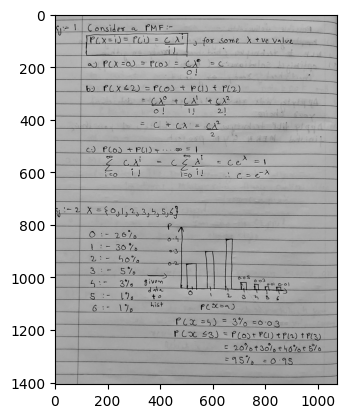

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

img = cv2.imread("notes.jpeg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img, cmap="gray")

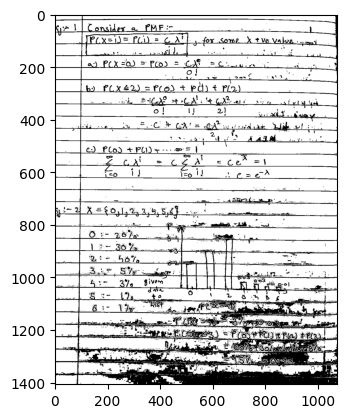

In [ ]:
# Simple thresholding
retval, binary = cv2.threshold(img, 150, 255, cv2.THRESH_BINARY)
plt.imshow(binary, cmap="gray")

# Adaptive Thresholding

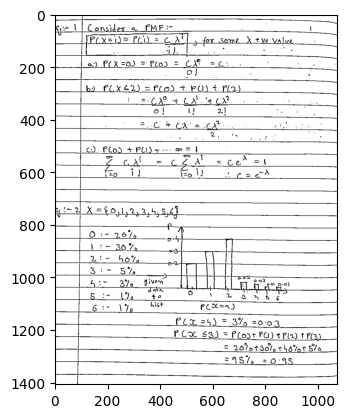

In [ ]:
# Mean adaptive thresholding
adaptive_m = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 15)
plt.imshow(adaptive_m, cmap="gray")

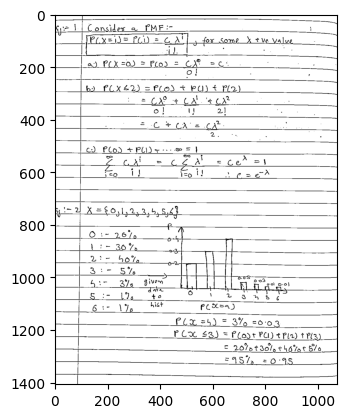

In [ ]:
# Gaussian adaptive thresholding
adaptive_g = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 15)
plt.imshow(adaptive_g, cmap="gray")

# Kmeans clustering

In [ ]:
img = cv2.imread("shapes.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
pixel_values = img.reshape((-1, 3))
pixel_values = np.float32(pixel_values)
print(pixel_values)

[[253. 253. 253.]
 [255. 255. 255.]
 [255. 255. 255.]
 ...
 [255. 255. 255.]
 [255. 255. 255.]
 [255. 255. 255.]]


In [ ]:
criteria_type = cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER #stop after a fixed no. of iterations and stop when improvement is small
max_iter = 100 # Run K-means for 100 iterations
epsilon = 0.2 # minimum movement of cluster centers
criteria = (criteria_type, max_iter, epsilon)

k = 3
initial_lables = None # assign cluster lables automatically
attempts = 10 #no. of times k-means is run with different initial cluster centers
retval, labels, centers = cv2.kmeans(pixel_values, k, initial_lables, criteria, attempts, cv2.KMEANS_RANDOM_CENTERS)
print(centers)

[[249.30463  115.969215  70.36464 ]
 [254.37059  254.0891   254.13684 ]
 [ 72.44784  112.32654  168.45499 ]]


In [ ]:
centers = np.uint8(centers)
segmented_img = centers[labels.flatten()] # replace every pixel by its cluster's color
segmented_img = segmented_img.reshape(img.shape)

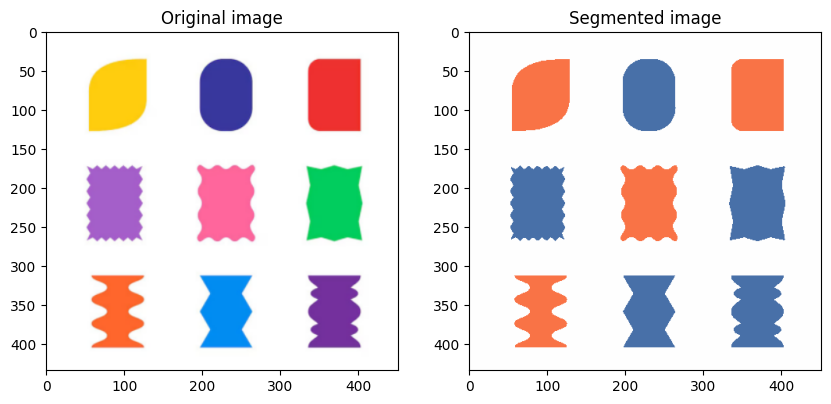

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original image")
plt.subplot(1, 2, 2)
plt.imshow(segmented_img)
plt.title("Segmented image")
plt.show()

# Watershed algorithm

1.   Convert the image to grayscale
2.   Apply binary threshold to create a binary img for separating foreground and background
3. Use morphological operations to remove noise
4. Compute the distance transform, which measures the distance from each pixel to the nearest background pixel
5. Label the foreground and background using markers
6. Use the watershed function to compute the watershed lines
7. Mark boundaries where watershed lines exist


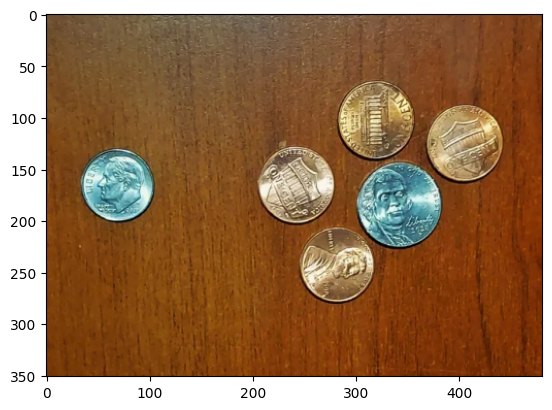

In [ ]:
img = cv2.imread("coins.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

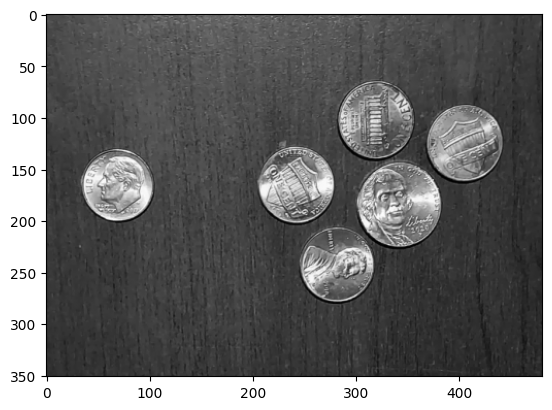

In [ ]:
# Converting to grayscale
grey_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(grey_img, cmap="gray")

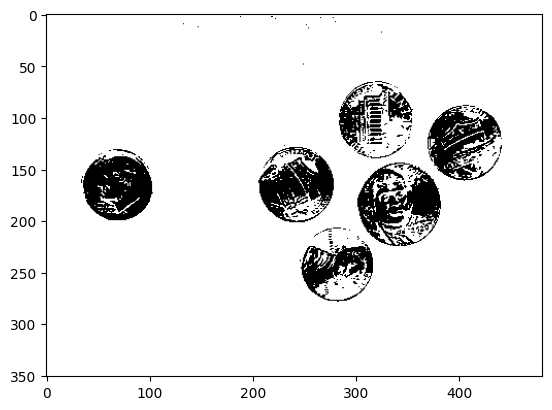

In [ ]:
# Thresholding
retval, binary = cv2.threshold(grey_img, 130, 255, cv2.THRESH_BINARY_INV)
plt.imshow(binary, cmap="gray")

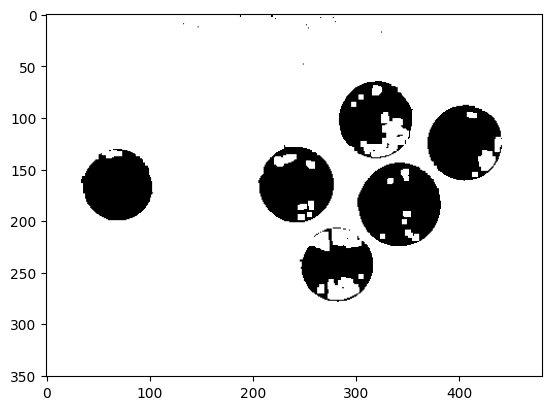

In [ ]:
# Morphological Opening to remove noise
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)
plt.imshow(opening, cmap="gray")

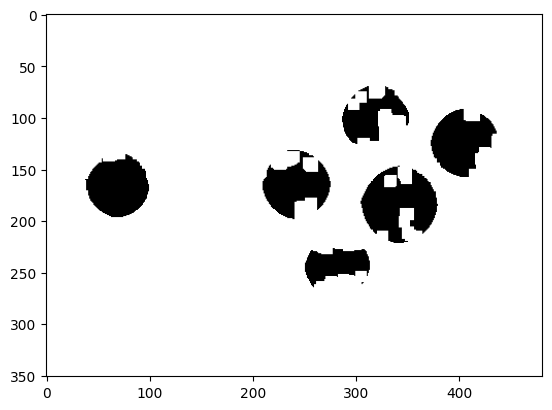

In [ ]:
# Dilation to get sure background
sure_bg = cv2.dilate(opening, kernel, iterations=3)
plt.imshow(sure_bg, cmap="gray")

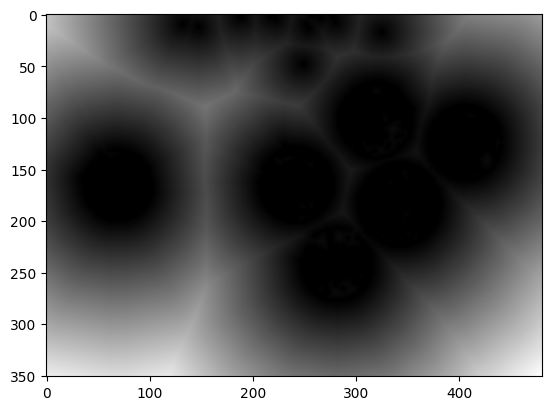

In [ ]:
# Distance transform to compute distance to nearest background using L2 (Euclidean distance) with a 5x5 mask
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
plt.imshow(dist_transform, cmap="gray")

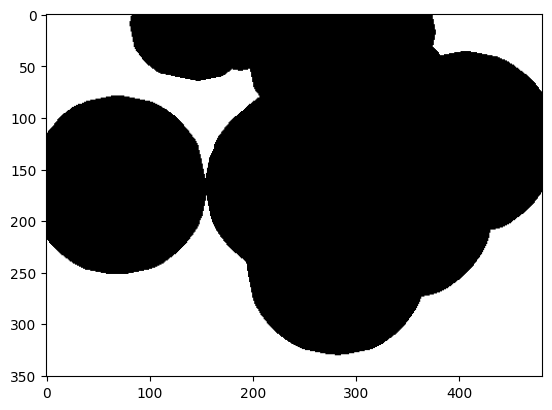

In [ ]:
# Thresholding the distance transform at 30% max value to obtain the sure foreground region
ret, sure_fg = cv2.threshold(dist_transform, 0.3*dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)
plt.imshow(sure_fg, cmap="gray")

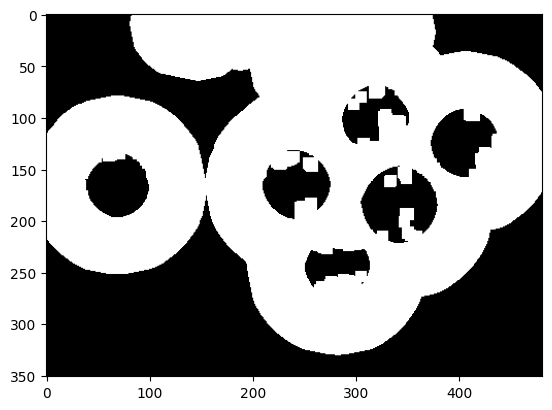

In [ ]:
# Subtracting sure_fg from sure_bg to obtain the unknown region
unknown = cv2.subtract(sure_bg, sure_fg)
plt.imshow(unknown, cmap="gray")

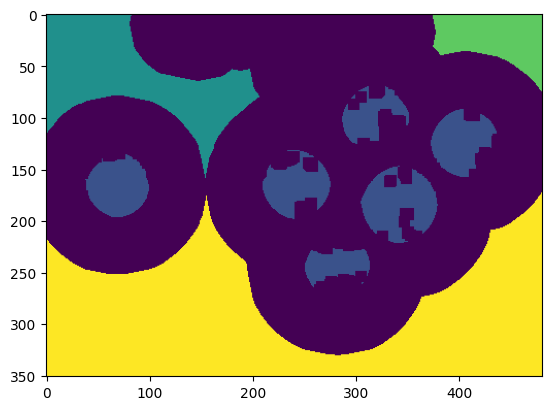

In [ ]:
# Marker creation
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown==255] = 0
plt.imshow(markers)

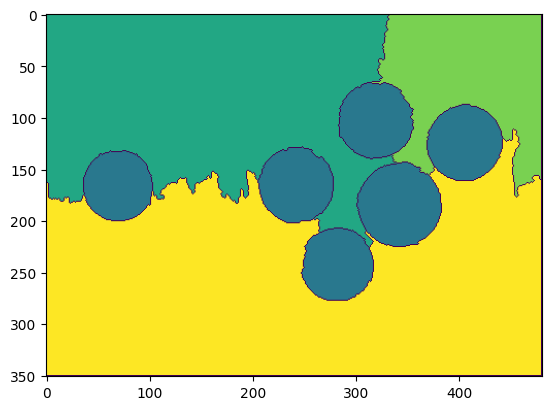

In [ ]:
# Watershed segmentation
markers = cv2.watershed(img, markers)
plt.imshow(markers)

In [ ]:
# Drawing contours and bounding boxes
original_img = img.copy()
coin_mask = np.zeros_like(grey_img)
unique_labels = np.unique(markers)
instance_number = 1
font = cv2.FONT_HERSHEY_SIMPLEX

for label in unique_labels:
  if label == 0 or label == -1:
    continue

  mask = np.uint8(markers == label)
  contours, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

  for contour in contours:
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)

    if perimeter == 0:
      continue

    # Circularity check
    circularity = (4 * np.pi * area) / (perimeter * perimeter)
    if 0.7 < circularity < 1.2 and area > 1000:
      cv2.drawContours(original_img, [contour], -1, (0, 255, 0), 2)
      x, y, w, h = cv2.boundingRect(contour)
      cv2.putText(original_img, f'Coin {instance_number}', (x, y-10), font, 0.6, (255,0,0), 2)
      coin_mask = cv2.bitwise_or(coin_mask, mask)
      cv2.rectangle(original_img, (x-5, y-5), (x+w+5, y+h+5), (160, 150, 250), 2)
      instance_number += 1

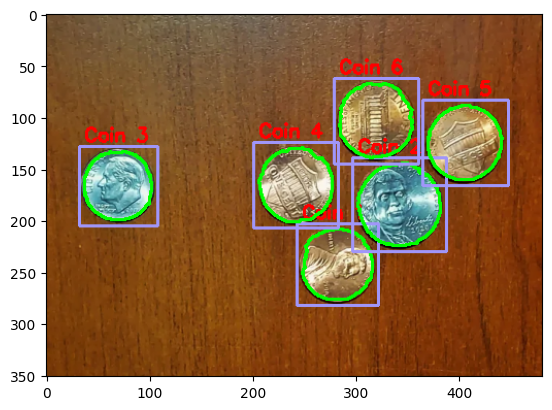

In [ ]:
plt.imshow(original_img)

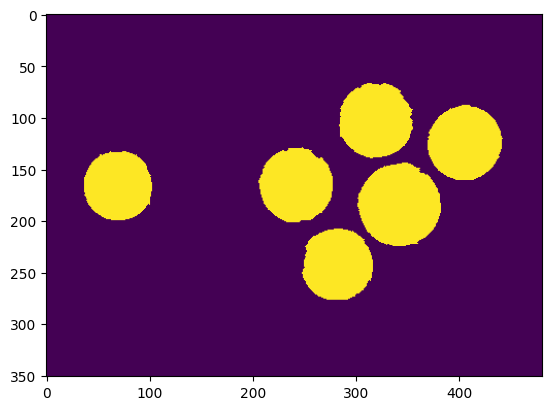

In [ ]:
plt.imshow(coin_mask)